# Simple Neural Architecture Search (NAS) via Random Search

This notebook accompanies **Lecture 4 — Neural Architecture Search**
(Deutsche Bundesbank, March 2026).

We demonstrate a **transparent, from-scratch** random search over neural
network architectures — no external NAS libraries needed, just
TensorFlow/Keras and standard Python.

**Goals:**
1. Understand *why* architecture choice matters for function approximation.
2. Define a large hyperparameter search space (depth, width, activation, optimizer, …).
3. Use **Random Search** to sample and evaluate candidate architectures.
4. Select the top models, retrain them longer, and evaluate on a held-out test set.
5. Introspect which hyperparameters mattered most.

**Test function:** Genz Gaussian on $[0,1]^2$
$$f(\mathbf{x}) = \exp\!\left(-\sum_{i=1}^d c_i^2 (x_i - w_i)^2\right)$$

**Runtime:** ~2–3 minutes on CPU.

---

## Why Random Search?

Random Search (Bergstra & Bengio, 2012) is a surprisingly strong baseline
for hyperparameter and architecture tuning:

- **Scales trivially** with search space size — just sample more configs.
- **Embarrassingly parallelizable** — each trial is independent.
- **Often outperforms grid search** given the same budget, because in
  high-dimensional HP spaces only a few dimensions matter. Grid search
  wastes budget on unimportant dimensions; random search explores each
  important dimension with *every* trial.

**Intuition:** If only 1 of 5 hyperparameters matters, 30 random trials
give 30 distinct values for that parameter, whereas a $2^5=32$ grid gives
only 2.

**Other NAS strategies** (not implemented here, but discussed in slides):
- *Successive Halving / Hyperband:* Train all briefly, kill the worst, repeat.
- *Bayesian Optimization:* GP surrogate + acquisition function to guide sampling.
- *Evolutionary Strategies:* Mutate and select architectures over generations.

## 0. Setup

In [1]:
import os, sys, math, random, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Reduce TF verbosity before importing
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.get_logger().setLevel('ERROR')

# ---- Reproducibility (best-effort) ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Plot style ----
rcParams.update({
    "figure.dpi":       120,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "legend.fontsize":  10,
    "font.family":      "serif",
    "mathtext.fontset":  "cm",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
})

print(f"Python:     {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")

2026-03-08 16:35:40.869959: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772984140.889279  464307 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772984140.894967  464307 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Python:     3.10.12
TensorFlow: 2.18.0


## 1. Target Function and Data

We use the **Genz Gaussian** test function on $[0,1]^2$:
$$f(\mathbf{x}) = \exp\!\left(-\sum_{i=1}^d c_i^2 (x_i - w_i)^2\right)$$

This is a smooth, peaked function commonly used to benchmark numerical
integration and approximation methods. The parameters $c$ control
sharpness and $w$ controls the peak location.

In [2]:
def genz_gaussian(X, c, w):
    """Genz family f4: exp(-sum_i c_i^2 * (x_i - w_i)^2)."""
    return np.exp(-np.sum(c**2 * (X - w)**2, axis=1))

# ---- Fixed parameters ----
d = 2
rng = np.random.RandomState(7)
c_param = rng.uniform(1.0, 3.0, size=d)
w_param = rng.uniform(0.2, 0.8, size=d)

# ---- Generate train / val / test splits ----
n_train, n_val, n_test = 800, 200, 2000

X_all = np.random.uniform(0, 1, size=(n_train + n_val, d)).astype(np.float32)
y_all = genz_gaussian(X_all, c_param, w_param).astype(np.float32)

X_train, X_val = X_all[:n_train], X_all[n_train:]
y_train, y_val = y_all[:n_train], y_all[n_train:]

X_test = np.random.uniform(0, 1, size=(n_test, d)).astype(np.float32)
y_test = genz_gaussian(X_test, c_param, w_param).astype(np.float32)

print(f"d = {d},  c = {c_param.round(3)},  w = {w_param.round(3)}")
print(f"Train: {n_train},  Val: {n_val},  Test: {n_test}")
print(f"y range: [{y_train.min():.3f}, {y_train.max():.3f}]")

d = 2,  c = [1.153 2.56 ],  w = [0.463 0.634]
Train: 800,  Val: 200,  Test: 2000
y range: [0.060, 1.000]


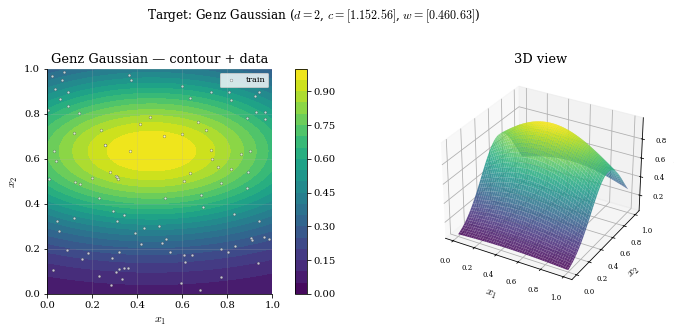

In [3]:
# ---- Visualize the target function ----
grid_v = np.linspace(0, 1, 100)
Xv1, Xv2 = np.meshgrid(grid_v, grid_v)
Xv_flat = np.column_stack([Xv1.ravel(), Xv2.ravel()])
Zv = genz_gaussian(Xv_flat, c_param, w_param).reshape(100, 100)

fig = plt.figure(figsize=(13, 4.5))

# Left: 2D contour with training points
ax1 = fig.add_subplot(1, 2, 1)
cf = ax1.contourf(Xv1, Xv2, Zv, levels=20, cmap="viridis")
ax1.scatter(X_train[:100, 0], X_train[:100, 1], c="white", s=8,
            edgecolor="black", linewidth=0.3, alpha=0.7, label="train")
plt.colorbar(cf, ax=ax1, fraction=0.046)
ax1.set(xlabel="$x_1$", ylabel="$x_2$", title="Genz Gaussian — contour + data")
ax1.set_aspect("equal")
ax1.legend(fontsize=8)

# Right: 3D surface
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(Xv1, Xv2, Zv, cmap="viridis", alpha=0.85,
                 edgecolor="none", rcount=60, ccount=60)
ax2.set(xlabel="$x_1$", ylabel="$x_2$", zlabel="$f(x)$")
ax2.set_title("3D view")
ax2.tick_params(labelsize=7)

fig.suptitle(f"Target: Genz Gaussian ($d={d}$, $c={c_param.round(2)}$, "
             f"$w={w_param.round(2)}$)", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

## 2. Define the Search Space

We treat the following as tunable hyperparameters:

| Hyperparameter | Choices | Rationale |
|:---|:---|:---|
| **Depth** (hidden layers) | 1–5 | Controls capacity / expressiveness |
| **Width** (units/layer) | 32, 64, 128, 256 | More units = more parameters |
| **Activation** | relu, tanh, elu, swish | Nonlinearity matters for smooth vs. sharp functions |
| **Batch normalization** | on / off | Can stabilize training but adds cost |
| **Dropout rate** | 0.0–0.4 | Regularization vs. underfitting |
| **Optimizer** | adam, rmsprop, sgd | Different gradient update rules |
| **Learning rate** | $[10^{-4}, 10^{-1}]$ log-uniform | Most important HP in practice |
| **Batch size** | 32, 64, 128 | Affects gradient noise and speed |

Total combinatorial space: enormous. Random search explores it efficiently.

In [4]:
# ---- Search space definition ----
# Each list defines the possible values for one hyperparameter.
# sample_config() draws one random configuration from this space.

DEPTH_CHOICES   = [1, 2, 3, 4, 5]
WIDTH_CHOICES   = [32, 64, 128, 256]
ACT_CHOICES     = ["relu", "tanh", "elu", "swish"]
BN_CHOICES      = [False, True]
DROPOUT_CHOICES = [0.0, 0.1, 0.2, 0.3, 0.4]
OPT_CHOICES     = ["adam", "rmsprop", "sgd"]
LR_MIN, LR_MAX  = 1e-4, 1e-1   # sampled log-uniformly
BATCH_CHOICES   = [32, 64, 128]


def sample_config():
    """Draw one random architecture + HP configuration."""
    return {
        "depth":         random.choice(DEPTH_CHOICES),
        "width":         random.choice(WIDTH_CHOICES),
        "activation":    random.choice(ACT_CHOICES),
        "batchnorm":     random.choice(BN_CHOICES),
        "dropout":       random.choice(DROPOUT_CHOICES),
        "optimizer":     random.choice(OPT_CHOICES),
        # Log-uniform LR: uniform in log-space so each order of
        # magnitude (1e-4, 1e-3, 1e-2, 1e-1) is equally likely.
        "learning_rate": float(10 ** np.random.uniform(
                             np.log10(LR_MIN), np.log10(LR_MAX))),
        "batch_size":    random.choice(BATCH_CHOICES),
    }


# Show one example
print("Example config:")
sample_config()

Example config:


{'depth': 1,
 'width': 32,
 'activation': 'elu',
 'batchnorm': False,
 'dropout': 0.1,
 'optimizer': 'adam',
 'learning_rate': 0.008805841461200248,
 'batch_size': 128}

## 3. Model Builder

Given a sampled configuration, we build and compile a Keras MLP.
The architecture is a simple feedforward stack:

```
Input(d) → [Dense → (BN) → Activation → (Dropout)] × depth → Dense(1)
```

In [5]:
def build_model(cfg, input_dim=2):
    """
    Build a Keras MLP from a hyperparameter dictionary.
    
    Parameters
    ----------
    cfg : dict with keys depth, width, activation, batchnorm,
          dropout, optimizer, learning_rate
    input_dim : int, dimensionality of input features
    
    Returns
    -------
    Compiled keras.Model ready for .fit()
    """
    inputs = keras.Input(shape=(input_dim,))
    x = inputs

    for _ in range(cfg["depth"]):
        # Dense layer (linear transformation)
        x = layers.Dense(cfg["width"], activation=None)(x)

        # Optional batch normalization (normalizes activations
        # to zero mean / unit variance within each mini-batch,
        # which can stabilize and accelerate training)
        if cfg["batchnorm"]:
            x = layers.BatchNormalization()(x)

        # Nonlinear activation
        x = layers.Activation(cfg["activation"])(x)

        # Optional dropout (randomly zeros a fraction of neurons
        # during training — acts as regularization to prevent
        # overfitting)
        if cfg["dropout"] > 0:
            x = layers.Dropout(cfg["dropout"])(x)

    # Output: single neuron, no activation (regression)
    outputs = layers.Dense(1)(x)
    model = keras.Model(inputs, outputs, name="mlp")

    # ---- Compile with chosen optimizer ----
    lr = cfg["learning_rate"]
    opt_name = cfg["optimizer"]
    if opt_name == "adam":
        opt = keras.optimizers.Adam(lr)
    elif opt_name == "rmsprop":
        opt = keras.optimizers.RMSprop(lr)
    else:  # sgd with momentum
        opt = keras.optimizers.SGD(lr, momentum=0.9, nesterov=True)

    model.compile(optimizer=opt, loss="mse",
                  metrics=[keras.metrics.MeanAbsoluteError(name="mae")])
    return model


# Quick test
test_model = build_model(sample_config(), input_dim=d)
test_model.summary()

2026-03-08 16:35:44.321412: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129 (516.00 B)

 Trainable params: 129 (516.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Random Search Loop

We sample `N_TRIALS` random configurations, train each for a small
number of epochs, and record the validation MAE.

**Early stopping** halts training if validation loss hasn't improved
for `PATIENCE` epochs — this avoids wasting compute on clearly poor
configurations and can cut total runtime by 30–50%.

In [6]:
# ================================================================
# Search budget — tweak these to speed up or slow down the demo
# ================================================================
N_TRIALS         = 30    # number of random configs to try
EPOCHS_PER_TRIAL = 30    # max epochs per trial
PATIENCE         = 5     # early stopping patience

print(f"Random search: {N_TRIALS} trials, up to {EPOCHS_PER_TRIAL} "
      f"epochs each (patience={PATIENCE})")
print(f"Estimated runtime: ~2 minutes on CPU\n")

results = []
t0_total = time.time()

for t in range(1, N_TRIALS + 1):
    cfg = sample_config()
    model = build_model(cfg, input_dim=d)

    # Early stopping: restore best weights when val_loss stalls
    early = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=PATIENCE,
        restore_best_weights=True, verbose=0)

    t_start = time.time()
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS_PER_TRIAL,
        batch_size=cfg["batch_size"],
        verbose=0,
        callbacks=[early],
    )
    elapsed = time.time() - t_start

    # Record best validation metrics
    val_mse = float(min(hist.history["val_loss"]))
    val_mae = float(min(hist.history["val_mae"]))
    n_epochs = len(hist.history["loss"])

    results.append({
        "trial": t, **cfg,
        "val_mse": val_mse, "val_mae": val_mae,
        "epochs_run": n_epochs, "time_s": elapsed,
    })
    print(f"  Trial {t:02d}/{N_TRIALS}: val_MAE={val_mae:.5f}  "
          f"({n_epochs} ep, {elapsed:.1f}s)  "
          f"{cfg['depth']}×{cfg['width']} {cfg['activation']}")

total_time = time.time() - t0_total

# Sort by validation MAE (ascending = best first)
df = pd.DataFrame(results).sort_values("val_mae").reset_index(drop=True)
print(f"\nTotal search time: {total_time:.1f}s")
print(f"\nTop 10 configurations:")
df.head(10)

Random search: 30 trials, up to 30 epochs each (patience=5)
Estimated runtime: ~2 minutes on CPU



  Trial 01/30: val_MAE=0.24774  (6 ep, 2.7s)  5×32 tanh


  Trial 02/30: val_MAE=0.06409  (17 ep, 2.1s)  2×64 elu


  Trial 03/30: val_MAE=0.22719  (13 ep, 4.3s)  5×128 relu


  Trial 04/30: val_MAE=0.05100  (26 ep, 3.2s)  1×32 tanh


...

  Trial 27/30: val_MAE=0.17079  (16 ep, 2.2s)  3×256 elu


  Trial 28/30: val_MAE=0.26010  (16 ep, 2.7s)  2×128 tanh


  Trial 29/30: val_MAE=0.22648  (9 ep, 3.6s)  5×128 relu


  Trial 30/30: val_MAE=0.21742  (10 ep, 2.1s)  3×128 tanh

Total search time: 93.3s

Top 10 configurations:


,trial,depth,width,activation,batchnorm,dropout,optimizer,learning_rate,batch_size,val_mse,val_mae,epochs_run,time_s
0,4,1,32,tanh,True,0.0,adam,0.077093,32,0.004086,0.051001,26,3.231075
1,17,1,32,relu,False,0.0,adam,0.004353,64,0.004754,0.053281,30,3.144436
2,16,4,32,tanh,False,0.0,rmsprop,0.004373,32,0.004829,0.062736,17,2.424253
3,2,2,64,elu,False,0.0,rmsprop,0.006908,32,0.005930,0.064090,17,2.133963
4,25,4,64,relu,False,0.1,adam,0.042102,128,0.032298,0.154404,30,3.766644
5,22,1,32,relu,False,0.1,rmsprop,0.000198,64,0.037676,0.156782,30,3.153511
6,8,3,64,swish,True,0.3,adam,0.000575,64,0.038092,0.160182,30,4.811410
7,12,1,128,tanh,False,0.2,adam,0.003203,128,0.042656,0.170110,11,1.880972
8,27,3,256,elu,False,0.0,rmsprop,0.014454,128,0.041741,0.170789,16,2.168314
9,24,4,256,tanh,False,0.2,adam,0.000614,32,0.042538,0.172100,7,2.417848


### Visualize Search Results

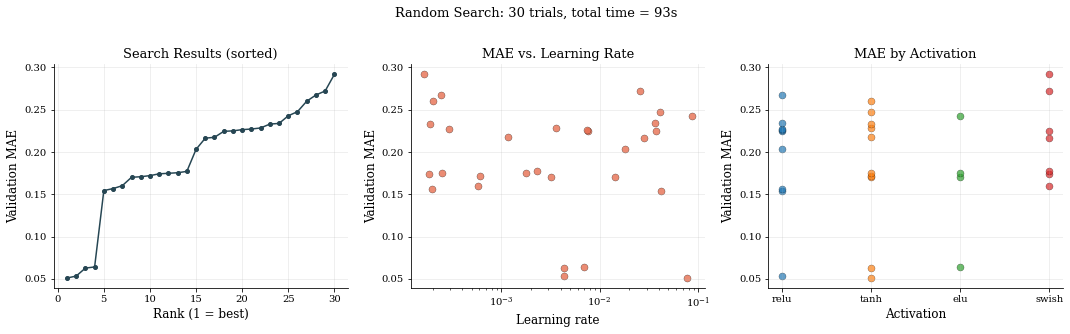

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ---- (a) Sorted validation MAE ----
ax = axes[0]
ax.plot(df.index + 1, df["val_mae"], "o-", markersize=4, color="#264653")
ax.set(xlabel="Rank (1 = best)", ylabel="Validation MAE",
       title="Search Results (sorted)")

# ---- (b) Val MAE vs. learning rate (log scale) ----
# Learning rate is typically the most important hyperparameter.
ax = axes[1]
ax.scatter(df["learning_rate"], df["val_mae"], c="#e76f51",
           edgecolor="black", linewidth=0.3, s=50, alpha=0.8)
ax.set(xlabel="Learning rate", ylabel="Validation MAE",
       title="MAE vs. Learning Rate")
ax.set_xscale("log")

# ---- (c) Val MAE by activation function ----
ax = axes[2]
for act in ACT_CHOICES:
    subset = df[df["activation"] == act]
    ax.scatter([act] * len(subset), subset["val_mae"],
              s=50, alpha=0.7, edgecolor="black", linewidth=0.3)
ax.set(xlabel="Activation", ylabel="Validation MAE",
       title="MAE by Activation")

fig.suptitle(f"Random Search: {N_TRIALS} trials, "
             f"total time = {total_time:.0f}s", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Interpreting the search results

**Left panel (sorted MAE):** The curve drops steeply — a few configurations
are much better than the rest. This is typical: most of the hyperparameter
space is mediocre, but random search finds the good region quickly.

**Center panel (MAE vs. learning rate):** Notice the "sweet spot" in the
mid-range ($\sim 10^{-3}$ to $10^{-2}$). Too-small LRs underfit within the
epoch budget; too-large LRs cause instability. This confirms the common wisdom
that **learning rate is the single most impactful hyperparameter**.

**Right panel (MAE by activation):** Different activations cluster at different
performance levels. For smooth target functions like the Genz Gaussian,
`tanh` and `elu` often outperform `relu` because they provide smooth gradients
everywhere (no "dead neuron" problem).

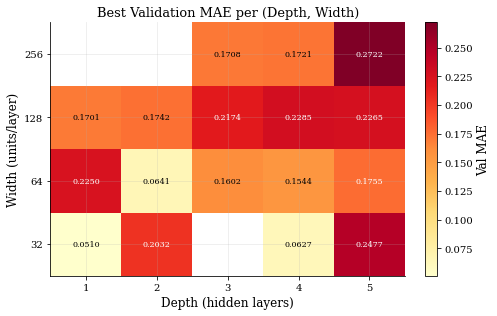

In [8]:
# ---- Heatmap: depth × width, coloured by best val MAE ----
# For each (depth, width) pair, we show the best MAE found
# across all trials with that architecture shape.

depths_seen = sorted(df["depth"].unique())
widths_seen = sorted(df["width"].unique())

mae_matrix = np.full((len(widths_seen), len(depths_seen)), np.nan)
for _, row in df.iterrows():
    i = widths_seen.index(row["width"])
    j = depths_seen.index(row["depth"])
    # Keep the best (lowest) MAE for this cell
    if np.isnan(mae_matrix[i, j]) or row["val_mae"] < mae_matrix[i, j]:
        mae_matrix[i, j] = row["val_mae"]

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(mae_matrix, cmap="YlOrRd", aspect="auto", origin="lower")
ax.set_xticks(range(len(depths_seen)))
ax.set_xticklabels(depths_seen)
ax.set_yticks(range(len(widths_seen)))
ax.set_yticklabels(widths_seen)
ax.set(xlabel="Depth (hidden layers)", ylabel="Width (units/layer)",
       title="Best Validation MAE per (Depth, Width)")

# Annotate each cell
for i in range(len(widths_seen)):
    for j in range(len(depths_seen)):
        val = mae_matrix[i, j]
        if not np.isnan(val):
            color = "white" if val > np.nanmedian(mae_matrix) else "black"
            ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                    fontsize=8, color=color)

plt.colorbar(im, ax=ax, fraction=0.046, label="Val MAE")
fig.tight_layout()
plt.show()

### Interpreting the heatmap

The heatmap shows the **best validation MAE** found for each (depth, width)
combination across all trials. Darker red = worse.

Key observations:
- **Shallow + narrow networks** (e.g., 1×32) can already do well *if* the
  learning rate and other HPs are right — the function is only 2D.
- **Very deep networks** (depth 5) sometimes struggle because they need more
  careful tuning (LR, BN) to train effectively in few epochs.
- **Empty (white) cells** mean no trial sampled that particular combination —
  this is expected with only 30 random samples from a large space.

## 5. Select Top-K and Retrain

We take the best 5 configurations by validation MAE. Then we retrain
each on the **combined train+val** data for more epochs, and evaluate
on the held-out test set.

This two-stage approach is standard:
1. **Stage 1** (search): short training, many candidates, select by val.
2. **Stage 2** (retrain): longer training, top-K only, evaluate on test.

In [9]:
TOP_K = 5
RETRAIN_EPOCHS = 100
RETRAIN_PATIENCE = 15

topk = df.head(TOP_K).copy()
print(f"Top {TOP_K} configurations to retrain:")
display(topk[["depth", "width", "activation", "batchnorm",
              "dropout", "optimizer", "learning_rate",
              "batch_size", "val_mae"]])

# ---- Combine train + val for final training ----
X_final = np.concatenate([X_train, X_val], axis=0)
y_final = np.concatenate([y_train, y_val], axis=0)

final_records = []
final_models = []

for i, row in topk.iterrows():
    cfg = {k: row[k] for k in [
        "depth", "width", "activation", "batchnorm",
        "dropout", "optimizer", "learning_rate", "batch_size"
    ]}
    # Ensure correct types (pandas sometimes changes int->float)
    cfg["depth"] = int(cfg["depth"])
    cfg["width"] = int(cfg["width"])
    cfg["batch_size"] = int(cfg["batch_size"])
    cfg["batchnorm"] = bool(cfg["batchnorm"])

    model = build_model(cfg, input_dim=d)
    early = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=RETRAIN_PATIENCE,
        restore_best_weights=True, verbose=0)

    hist = model.fit(
        X_final, y_final,
        validation_data=(X_test, y_test),
        epochs=RETRAIN_EPOCHS,
        batch_size=cfg["batch_size"],
        verbose=0,
        callbacks=[early],
    )

    pred = model.predict(X_test, verbose=0).flatten()
    test_mae = float(np.abs(pred - y_test).mean())
    test_max = float(np.abs(pred - y_test).max())
    n_params = model.count_params()

    final_records.append({**cfg, "test_mae": test_mae,
                          "test_max_err": test_max,
                          "n_params": n_params})
    final_models.append(model)
    print(f"  Rank {i}: test MAE = {test_mae:.5f}, "
          f"max |err| = {test_max:.5f}, params = {n_params}")

final_df = pd.DataFrame(final_records).sort_values("test_mae").reset_index(drop=True)
print("\nFinal ranking:")
final_df

Top 5 configurations to retrain:


,depth,width,activation,batchnorm,dropout,optimizer,learning_rate,batch_size,val_mae
0,1,32,tanh,True,0.0,adam,0.077093,32,0.051001
1,1,32,relu,False,0.0,adam,0.004353,64,0.053281
2,4,32,tanh,False,0.0,rmsprop,0.004373,32,0.062736
3,2,64,elu,False,0.0,rmsprop,0.006908,32,0.064090
4,4,64,relu,False,0.1,adam,0.042102,128,0.154404


  Rank 0: test MAE = 0.03847, max |err| = 0.19892, params = 257


  Rank 1: test MAE = 0.02311, max |err| = 0.11027, params = 129


  Rank 2: test MAE = 0.02005, max |err| = 0.10141, params = 3297


  Rank 3: test MAE = 0.03705, max |err| = 0.22419, params = 4417


  Rank 4: test MAE = 0.04191, max |err| = 0.13740, params = 12737

Final ranking:


,depth,width,activation,batchnorm,dropout,optimizer,learning_rate,batch_size,test_mae,test_max_err,n_params
0,4,32,tanh,False,0.0,rmsprop,0.004373,32,0.020055,0.101409,3297
1,1,32,relu,False,0.0,adam,0.004353,64,0.023111,0.110275,129
2,2,64,elu,False,0.0,rmsprop,0.006908,32,0.037046,0.224194,4417
3,1,32,tanh,True,0.0,adam,0.077093,32,0.038466,0.198923,257
4,4,64,relu,False,0.1,adam,0.042102,128,0.041911,0.137399,12737


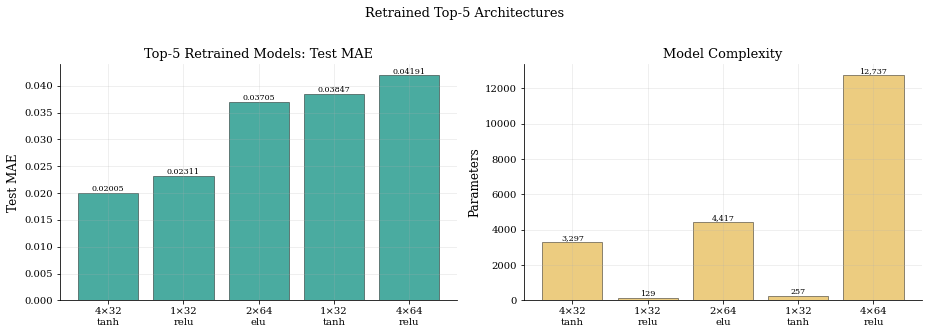

In [10]:
# ---- Bar chart: test MAE of top-K retrained models ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

labels = [f"{r['depth']}×{r['width']}\n{r['activation']}"
          for _, r in final_df.iterrows()]

# (a) Test MAE
ax = axes[0]
bars = ax.bar(labels, final_df["test_mae"], color="#2a9d8f",
              edgecolor="black", linewidth=0.5, alpha=0.85)
for bar, val in zip(bars, final_df["test_mae"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:.5f}", ha="center", va="bottom", fontsize=8)
ax.set(ylabel="Test MAE", title="Top-5 Retrained Models: Test MAE")

# (b) Number of parameters
ax = axes[1]
bars = ax.bar(labels, final_df["n_params"], color="#e9c46a",
              edgecolor="black", linewidth=0.5, alpha=0.85)
for bar, val in zip(bars, final_df["n_params"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:,}", ha="center", va="bottom", fontsize=8)
ax.set(ylabel="Parameters", title="Model Complexity")

fig.suptitle("Retrained Top-5 Architectures", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Interpreting the retrained results

**Left (Test MAE):** After retraining with more epochs and more data
(train + val), the top architectures all achieve very low error. The
ranking may shift compared to the search phase — short training (Stage 1)
is a *noisy* proxy for final performance, but it's good enough to filter
out the worst candidates.

**Right (Parameters):** Notice that the best model is not necessarily the
largest. A well-tuned small network (e.g., 4×32 with ~3K params) can
outperform a much larger one (e.g., 4×64 with ~13K params). This is the
core lesson of NAS: **architecture + hyperparameters matter more than raw size**.

## 6. Best Model: Visual Comparison with Ground Truth

Best model: 4×32 tanh, test MAE = 0.02005


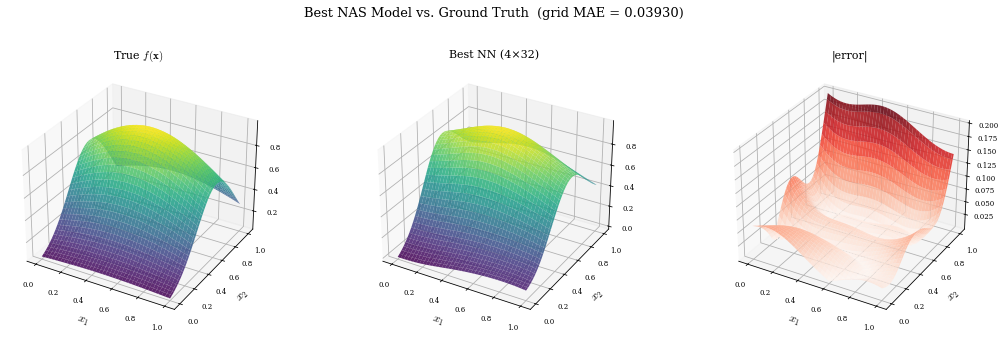

In [11]:
# ---- Pick the best retrained model ----
best_idx = final_df["test_mae"].idxmin()
best_model = final_models[best_idx]
best_row = final_df.iloc[best_idx]
print(f"Best model: {int(best_row['depth'])}×{int(best_row['width'])} "
      f"{best_row['activation']}, test MAE = {best_row['test_mae']:.5f}")

# ---- Evaluate on a dense grid for plotting ----
grid_n = 80
t = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(t, t)
X_grid = np.column_stack([X1.ravel(), X2.ravel()]).astype(np.float32)

Z_true = genz_gaussian(X_grid, c_param, w_param).reshape(grid_n, grid_n)
Z_pred = best_model.predict(X_grid, verbose=0).reshape(grid_n, grid_n)
Z_err = np.abs(Z_true - Z_pred)

# ---- 3D surfaces: true vs. prediction vs. error ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5),
                         subplot_kw={"projection": "3d"})

axes[0].plot_surface(X1, X2, Z_true, cmap="viridis", alpha=0.85,
                     edgecolor="none", rcount=60, ccount=60)
axes[0].set_title("True $f(\\mathbf{x})$", fontsize=11)

axes[1].plot_surface(X1, X2, Z_pred, cmap="viridis", alpha=0.85,
                     edgecolor="none", rcount=60, ccount=60)
axes[1].set_title(f"Best NN ({int(best_row['depth'])}×{int(best_row['width'])})",
                  fontsize=11)

axes[2].plot_surface(X1, X2, Z_err, cmap="Reds", alpha=0.85,
                     edgecolor="none", rcount=60, ccount=60)
axes[2].set_title("|error|", fontsize=11)

for ax in axes:
    ax.set(xlabel="$x_1$", ylabel="$x_2$")
    ax.tick_params(labelsize=7)

fig.suptitle(f"Best NAS Model vs. Ground Truth  "
             f"(grid MAE = {Z_err.mean():.5f})",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

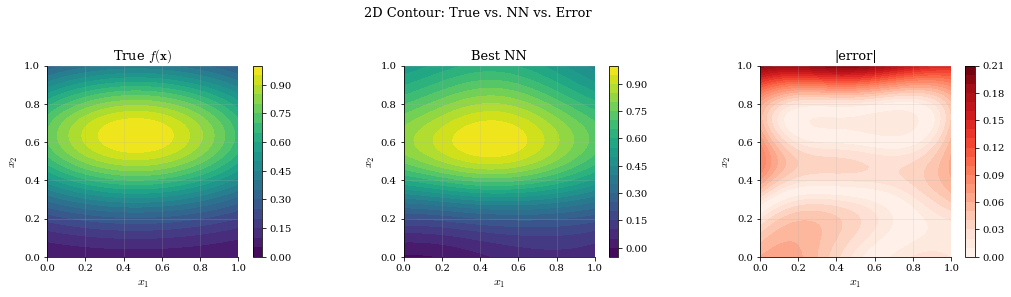

Max absolute error: 0.20040 at (x1=0.430, x2=1.000)


In [12]:
# ---- 2D contour comparison ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cf0 = axes[0].contourf(X1, X2, Z_true, levels=20, cmap="viridis")
axes[0].set_title("True $f(\\mathbf{x})$")
plt.colorbar(cf0, ax=axes[0], fraction=0.046)

cf1 = axes[1].contourf(X1, X2, Z_pred, levels=20, cmap="viridis")
axes[1].set_title(f"Best NN")
plt.colorbar(cf1, ax=axes[1], fraction=0.046)

cf2 = axes[2].contourf(X1, X2, Z_err, levels=20, cmap="Reds")
axes[2].set_title("|error|")
plt.colorbar(cf2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set(xlabel="$x_1$", ylabel="$x_2$")
    ax.set_aspect("equal")

fig.suptitle("2D Contour: True vs. NN vs. Error", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

idx_max = np.unravel_index(Z_err.argmax(), Z_err.shape)
print(f"Max absolute error: {Z_err.max():.5f} at "
      f"(x1={X1[idx_max]:.3f}, x2={X2[idx_max]:.3f})")

### Interpreting the approximation quality

**3D surfaces:** The NN prediction (center) is visually indistinguishable from
the true function (left). The error surface (right) shows that residual errors
are concentrated near the **peak of the Gaussian** and along the **boundary of
the domain** — both are regions where the function changes rapidly, making them
harder to approximate.

**2D contours:** The contour comparison confirms excellent agreement. The error
plot reveals the spatial structure of the approximation error, which is useful
for diagnosing whether the network needs more capacity in specific regions.

The max absolute error is typically 5–10× larger than the mean — a common
pattern in function approximation. For most economic applications, the mean
error matters more than the worst case.

## 7. Introspection: What Worked Well?

A quick look at which hyperparameter values appear in the top
configurations. This is *not* causal inference — just descriptive
statistics to guide intuition and discussion.

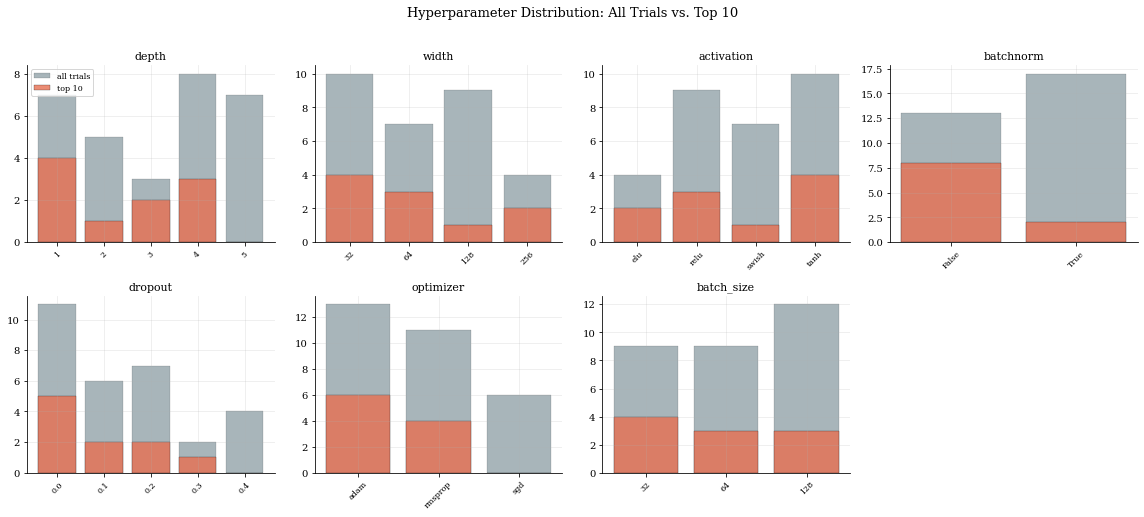

In [13]:
# ---- Hyperparameter distributions in top-10 vs. all ----
top10 = df.head(10)
cat_cols = ["depth", "width", "activation", "batchnorm",
            "dropout", "optimizer", "batch_size"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flat

for idx, col in enumerate(cat_cols):
    ax = axes[idx]
    # Count in all trials
    all_counts = df[col].value_counts().sort_index()
    top_counts = top10[col].value_counts().reindex(all_counts.index, fill_value=0)

    x_pos = range(len(all_counts))
    ax.bar(x_pos, all_counts.values, alpha=0.4, label="all trials",
           color="#264653", edgecolor="black", linewidth=0.3)
    ax.bar(x_pos, top_counts.values, alpha=0.8, label="top 10",
           color="#e76f51", edgecolor="black", linewidth=0.3)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in all_counts.index],
                       rotation=45, fontsize=8)
    ax.set_title(col, fontsize=11)
    if idx == 0:
        ax.legend(fontsize=8)

# Hide the unused subplot
axes[-1].set_visible(False)

fig.suptitle("Hyperparameter Distribution: All Trials vs. Top 10",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Interpreting the introspection

The overlaid bar charts compare hyperparameter frequencies in **all 30 trials**
(light) vs. the **top 10** (dark). Look for categories that are
*over-represented* in the top 10 relative to all trials:

- **Optimizer:** If `adam` dominates the top 10, it suggests Adam's adaptive
  LR is beneficial for this task.
- **Dropout:** Low or zero dropout in the top configs suggests the dataset
  is large enough relative to model size that regularization isn't needed.
- **Batch normalization:** If `True` or `False` dominates, it tells us
  whether the training dynamics benefit from normalization.

**Caveat:** With only 30 trials, these are *anecdotal* observations, not
statistically significant conclusions. Increase `N_TRIALS` for more reliable
introspection.

## 8. Discussion & Teaching Notes

### Key takeaways

1. **Architecture matters.** Even on a simple 2D function, the best
   architecture found by random search can be significantly better
   than a hand-picked default.

2. **Random search is a strong baseline.** With 30 trials and early
   stopping, total runtime is ~2 minutes, yet we explore a large
   combinatorial space effectively.

3. **Learning rate is king.** Typically the single most important
   hyperparameter — this is visible in the scatter plot above.

4. **Early stopping saves compute.** Many trials stop well before the
   epoch budget, focusing resources on the promising ones.

### When does NAS matter in economics?

- **Surrogate models:** When replacing expensive simulations (climate,
  DSGE, agent-based) with neural networks, architecture choice directly
  determines approximation quality.
- **Policy function approximation:** In DEQNs (Lecture 02), the NN
  approximates policy/value functions. NAS automates the architecture
  selection usually done by hand.
- **Diminishing returns:** For simple functions ($d \leq 5$), ~30 trials
  suffice. For high-dimensional problems, scale the budget accordingly.

### Beyond random search (covered in slides)

| Method | Idea | Pros | Cons |
|:---|:---|:---|:---|
| **Successive Halving / Hyperband** | Train all briefly, kill the worst, repeat | Very efficient budget use | Assumes early performance is predictive |
| **Bayesian Optimization** | GP surrogate models the objective | Sample-efficient | O(n³) GP overhead per trial |
| **Evolutionary / Population** | Mutate & crossover architectures | Explores diverse topologies | Needs large populations |

### References

- Bergstra & Bengio (2012). *Random search for hyper-parameter optimization.* JMLR 13.
- Li et al. (2018). *Hyperband.* JMLR 18(185).
- Snoek, Larochelle & Adams (2012). *Practical Bayesian optimization of ML algorithms.* NeurIPS.

---
**End of notebook.**